# V22: Portfolio Strategy Comparison - RF vs XGBoost & Graph Filter

This notebook compares two AI models (**Random Forest** and **XGBoost**) as risk-gatekeepers in a Markowitz portfolio, while evaluating the impact of a **Graph Filter (MIS)** for asset selection.

### Models in this Comparison:
1. **Markowitz Only**: Standard Mean-Variance Optimization (Baseline).
2. **RF-Gated Markowitz**: Risk-On/Off based on Random Forest predictions.
3. **XGB-Gated Markowitz**: Risk-On/Off based on XGBoost predictions.
4. **RF + Graph**: RF-Gating combined with Graph-based (MIS) asset selection.
5. **XGB + Graph**: XGB-Gating combined with Graph-based (MIS) asset selection.
6. **BTC Benchmark**: Buy and Hold Bitcoin.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data ---
file_path = 'dataset_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = '../dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 990 rows


In [2]:
# --- 2. Model Training ---
print("Training AI Gatekeepers (Random Forest and XGBoost)...")

# Feature Engineering
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()
features = features.dropna()
target = (market_return.shift(-1) > 0).astype(int).reindex(features.index).fillna(0)

train_mask = (features.index.year >= 2023) & (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

# 1. Random Forest Model
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_probs = pd.Series(rf_model.predict_proba(X_test)[:, 1], index=X_test.index)

# 2. XGBoost Model
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=X_test.index)

print("✓ Training Complete.")

Training AI Gatekeepers (Random Forest and XGBoost)...
✓ Training Complete.


In [3]:
# --- 3. Core Strategy Logic ---

def get_mis_assets(returns_window, correlation_threshold=0.5):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    assets = returns_window.columns
    G.add_nodes_from(assets)
    for i in range(len(assets)):
        for j in range(i+1, len(assets)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold:
                G.add_edge(assets[i], assets[j])
    mis = nx.approximation.maximum_independent_set(G)
    return list(mis)

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    
    def neg_sharpe(weights):
        port_ret = np.sum(weights * mu)
        port_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -port_ret / port_vol if port_vol > 0.0001 else 0
    
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(len(mu)))
    guess = [1. / len(mu)] * len(mu)
    
    try:
        res = minimize(neg_sharpe, guess, method='SLSQP', bounds=bounds, constraints=constraints)
        return dict(zip(selected_returns.columns, res.x)) if res.success else dict(zip(selected_returns.columns, guess))
    except:
        return dict(zip(selected_returns.columns, guess))

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, lookback=30, cor_t=0.5):
    val = 100.0
    history = [val]
    dates = [test_dates[0]]
    weights_log = []
    
    for i, date in enumerate(test_dates[:-1]):
        # 1. Gate Logic
        if strategy_type == 'Markowitz Only':
            is_risk_off = False
        else:
            is_risk_off = ai_probs.loc[date] < 0.5
        
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-lookback:loc_idx]
        
        if is_risk_off:
            weights = {'CASH': 1.0}
        else:
            use_graph = 'Graph' in label or 'Graph' in strategy_type
            if use_graph:
                selected = get_mis_assets(window_rets, correlation_threshold=cor_t)
                weights = optimize_markowitz(window_rets[selected])
            else:
                weights = optimize_markowitz(window_rets)
        
        weights_log.append(weights)
        
        # 2. PnL Calculation
        next_date = test_dates[i+1]
        next_rets = returns.loc[next_date]
        day_ret = 0 if 'CASH' in weights else sum(w * next_rets[a] for a, w in weights.items())
        
        val *= (1 + day_ret)
        history.append(val)
        dates.append(next_date)
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates), weights_log

In [4]:
# --- 4. Backtest Execution ---
test_dates = rf_probs.index
results = {}
all_weights = {}

sim_configs = [
    ('Markowitz Only', 'Markowitz Only', None),
    ('AI-Gated', 'RF-Gated Markowitz', rf_probs),
    ('AI-Gated', 'XGB-Gated Markowitz', xgb_probs),
    ('AI+Graph', 'RF + Graph Enhanced', rf_probs),
    ('AI+Graph', 'XGB + Graph Enhanced', xgb_probs)
]

for s_type, label, probs in sim_configs:
    print(f"Running sim: {label}...")
    df, w = run_simulation(s_type, test_dates, returns, probs)
    results[label] = df
    all_weights[label] = w

# BTC Benchmark
btc = data.loc[test_dates, 'BTC-USD']
results['Buy and Hold (BTC)'] = pd.DataFrame({'Portfolio_Value': (btc / btc.iloc[0] * 100)}, index=test_dates)

print("✓ Backtests Finished.")

Running sim: Markowitz Only...
Running sim: RF-Gated Markowitz...
Running sim: XGB-Gated Markowitz...
Running sim: RF + Graph Enhanced...
Running sim: XGB + Graph Enhanced...
✓ Backtests Finished.


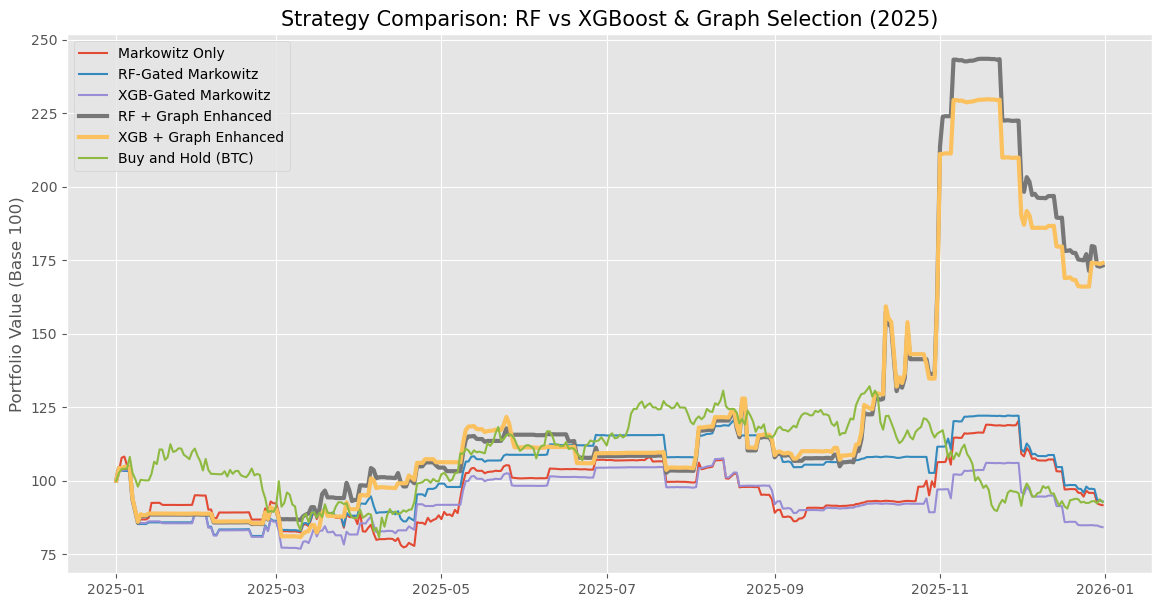

In [5]:
# --- 5. Visualization ---
plt.figure(figsize=(14, 7))
for label, df in results.items():
    linewidth = 3 if "Graph" in label else 1.5
    plt.plot(df.index, df['Portfolio_Value'], label=label, linewidth=linewidth)

plt.title("Strategy Comparison: RF vs XGBoost & Graph Selection (2025)", fontsize=15)
plt.ylabel("Portfolio Value (Base 100)")
plt.legend(loc='upper left')
plt.grid(True)
plt.savefig('v22_rf_xgb_graph_comparison.png', dpi=300)
plt.show()

In [6]:
# --- 6. Export Results ---
with pd.ExcelWriter('v22_portfolio_results_rf_xgb.xlsx') as writer:
    for label, df in results.items():
        df.to_excel(writer, sheet_name=label[:31])
print("✓ Results exported to v22_portfolio_results_rf_xgb.xlsx")

✓ Results exported to v22_portfolio_results_rf_xgb.xlsx
